In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


PALETTE = {
    'main'  : '#2563EB',
    'accent': '#F59E0B',
    'green' : '#10B981',
    'red'   : '#EF4444',
    'purple': '#7C3AED',
    'gray'  : '#6B7280'
}


In [28]:
df=pd.read_csv(r'..\data\historical_data.csv')
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


In [36]:
print(f'Dataframe shape:{df.shape}')
print(f'Columns: {list(df.columns)}')

Dataframe shape:(197428, 16)
Columns: ['market_id', 'created_at', 'actual_delivery_time', 'store_id', 'store_primary_category', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'estimated_order_place_duration', 'estimated_store_to_consumer_driving_duration']


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     196441 non-null  float64
 1   created_at                                    197428 non-null  object 
 2   actual_delivery_time                          197421 non-null  object 
 3   store_id                                      197428 non-null  int64  
 4   store_primary_category                        192668 non-null  object 
 5   order_protocol                                196433 non-null  float64
 6   total_items                                   197428 non-null  int64  
 7   subtotal                                      197428 non-null  int64  
 8   num_distinct_items                            197428 non-null  int64  
 9   min_item_price                                19

In [48]:
df.describe().round(2)

,market_id,store_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
count,196441.00,197428.00,196433.00,197428.00,197428.00,197428.00,197428.00,197428.00,181166.00,181166.00,181166.00,197428.00,196902.00
mean,2.98,3530.51,2.88,3.20,2682.33,2.67,686.22,1159.59,44.81,41.74,58.05,308.56,545.36
std,1.52,2053.50,1.50,2.67,1823.09,1.63,522.04,558.41,34.53,32.15,52.66,90.14,219.35
min,1.00,1.00,1.00,1.00,0.00,1.00,-86.00,0.00,-4.00,-5.00,-6.00,0.00,0.00
25%,2.00,1686.00,1.00,2.00,1400.00,1.00,299.00,800.00,17.00,15.00,17.00,251.00,382.00
50%,3.00,3592.00,3.00,3.00,2200.00,2.00,595.00,1095.00,37.00,34.00,41.00,251.00,544.00
75%,4.00,5299.00,4.00,4.00,3395.00,3.00,949.00,1395.00,65.00,62.00,85.00,446.00,702.00
max,6.00,6987.00,7.00,411.00,27100.00,20.00,14700.00,14700.00,171.00,154.00,285.00,2715.00,2088.00


## EDA


In [50]:
missing = df.isnull().sum()
missing_pct = (missing/len(df))*100
print(f"Missing values are {missing},percent is {missing_pct.round(2)}")

Missing values are market_id                                         987
created_at                                          0
actual_delivery_time                                7
store_id                                            0
store_primary_category                           4760
order_protocol                                    995
total_items                                         0
subtotal                                            0
num_distinct_items                                  0
min_item_price                                      0
max_item_price                                      0
total_onshift_dashers                           16262
total_busy_dashers                              16262
total_outstanding_orders                        16262
estimated_order_place_duration                      0
estimated_store_to_consumer_driving_duration      526
dtype: int64,percent is market_id                                       0.50
created_at                              

In [62]:
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing_df.to_string())

                                              Missing Count  Missing %
total_onshift_dashers                                 16262   8.236927
total_busy_dashers                                    16262   8.236927
total_outstanding_orders                              16262   8.236927
store_primary_category                                 4760   2.411006
order_protocol                                          995   0.503981
market_id                                               987   0.499929
estimated_store_to_consumer_driving_duration            526   0.266426
actual_delivery_time                                      7   0.003546


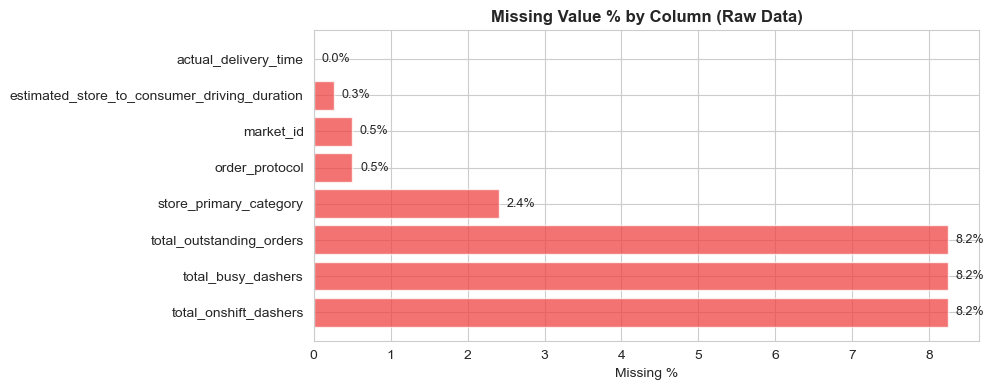

In [63]:
fig, ax = plt.subplots(figsize=(10, 4))
cols = missing_df.index.tolist()
pcts = missing_df['Missing %'].values

bars = ax.barh(cols, pcts, color=PALETTE['red'], alpha=0.75, edgecolor='white')
ax.set_xlabel('Missing %')
ax.set_title('Missing Value % by Column (Raw Data)', fontweight='bold')
for bar, val in zip(bars, pcts):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


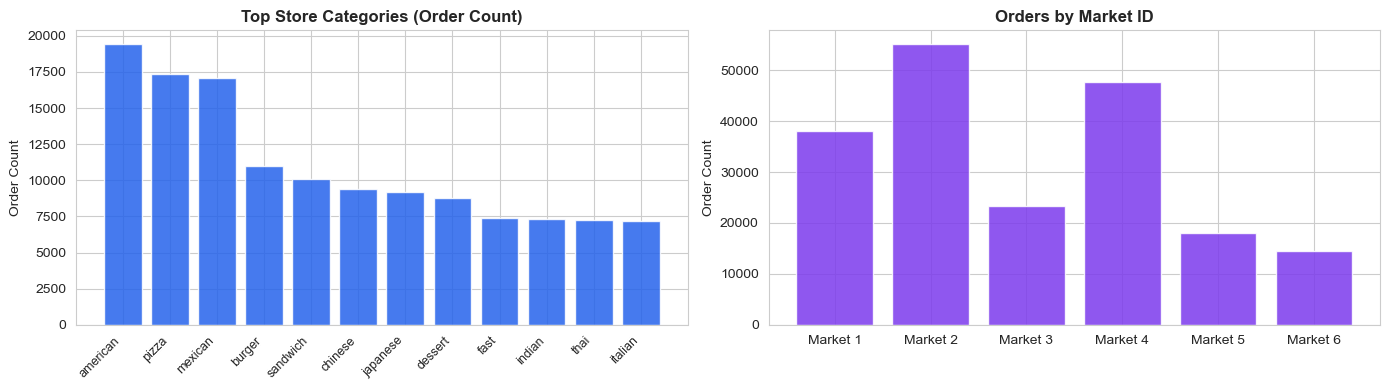

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Store category distribution
cat_counts = df['store_primary_category'].value_counts().head(12)
axes[0].bar(range(len(cat_counts)), cat_counts.values,
            color=PALETTE['main'], alpha=0.85, edgecolor='white')
axes[0].set_xticks(range(len(cat_counts)))
axes[0].set_xticklabels(cat_counts.index, rotation=45, ha='right', fontsize=9)
axes[0].set_title('Top Store Categories (Order Count)', fontweight='bold')
axes[0].set_ylabel('Order Count')


# Market distribution
mkt_counts = df['market_id'].value_counts().sort_index()
axes[1].bar([f'Market {int(m)}' for m in mkt_counts.index],
            mkt_counts.values, color=PALETTE['purple'], alpha=0.85, edgecolor='white')
axes[1].set_title('Orders by Market ID', fontweight='bold')
axes[1].set_ylabel('Order Count')

plt.tight_layout()
plt.show()


In [73]:
df_copy = df.copy()

print("=== BEFORE CLEANING ===")
print(f"Rows: {len(df_copy):,}")
print(f"Nulls:\n{df_copy.isnull().sum()[df_copy.isnull().sum() > 0].to_string()}")

=== BEFORE CLEANING ===
Rows: 197,428
Nulls:
market_id                                         987
actual_delivery_time                                7
store_primary_category                           4760
order_protocol                                    995
total_onshift_dashers                           16262
total_busy_dashers                              16262
total_outstanding_orders                        16262
estimated_store_to_consumer_driving_duration      526
actual_duration_mins                                7


In [74]:
df_copy['created_at']           = pd.to_datetime(df_copy['created_at'])
df_copy['actual_delivery_time'] = pd.to_datetime(df_copy['actual_delivery_time'])

print(f'Date range {df_copy["created_at"].min()} to {df_copy["created_at"].max()}')

Date range 2014-10-19 05:24:15 to 2015-02-18 06:00:44


In [75]:
df_copy['actual_duration_mins'] = (
    (df_copy['actual_delivery_time'] - df_copy['created_at'])
    .dt.total_seconds() / 60.0
)

In [77]:
df_copy['estimated_total_mins'] = (
    df_copy['estimated_order_place_duration'] +
    df_copy['estimated_store_to_consumer_driving_duration'].fillna(0)
) / 60.0

In [78]:
print("✅ Duration columns computed")
print(f"   Actual delivery: min={df_copy['actual_duration_mins'].min():.1f}  "
      f"max={df_copy['actual_duration_mins'].max():.0f}  "
      f"median={df_copy['actual_duration_mins'].median():.1f} mins")

✅ Duration columns computed
   Actual delivery: min=1.7  max=141948  median=44.3 mins


In [ ]:
length =len(df_copy)
df_copy = df_copy.dropna(subset=['actual_delivery_time', 'created_at'])
print(f" Dropped rows with missing timestamps: {length - len(df_copy):,} rows removed")

 Dropped rows with missing timestamps: 7 rows removed


In [92]:
before = len(df_copy)
df_copy = df_copy[(df_copy['actual_duration_mins'] >= 5) & (df_copy['actual_duration_mins'] <= 120)]
print(f" Removed {before - len(df_copy)} outlier rows (outside 5-120 min range)")

 Removed 1093 outlier rows (outside 5-120 min range)


In [94]:
print(f"\n Clean rows: {len(df_copy):,}")



 Clean rows: 196,328


In [98]:
## fill nulls with median and mode
median_cols = ['total_onshift_dashers', 'total_busy_dashers',
               'total_outstanding_orders',
               'estimated_store_to_consumer_driving_duration']

for col in median_cols:
    median_val = df_copy[col].median()
    nulls = df_copy[col].isnull().sum()
    df_copy[col] = df_copy[col].fillna(median_val)
    print(f"   Filled {nulls:>5} nulls in '{col}' with median={median_val:.1f}")

# market_id → mode
mode_market = df_copy['market_id'].mode()[0]
df_copy['market_id'] = df_copy['market_id'].fillna(mode_market)
print(f"   Filled market_id nulls with mode={int(mode_market)}")

# order_protocol → mode
df_copy['order_protocol'] = df_copy['order_protocol'].fillna(df_copy['order_protocol'].mode()[0])

# category → 'Unknown'
df_copy['store_primary_category'] = df_copy['store_primary_category'].replace('NA', 'Unknown').fillna('Unknown')


print(f"   Remaining nulls: {df_copy.isnull().sum().sum()}")


   Filled     0 nulls in 'total_onshift_dashers' with median=37.0
   Filled     0 nulls in 'total_busy_dashers' with median=34.0
   Filled     0 nulls in 'total_outstanding_orders' with median=41.0
   Filled     0 nulls in 'estimated_store_to_consumer_driving_duration' with median=543.0
   Filled market_id nulls with mode=2
   Remaining nulls: 0


In [ ]:
(df_copy['actual_duration_mins']<0).value_counts()

actual_duration_mins
False    197428
Name: count, dtype: int64

In [117]:
df_copy['hour_of_day']  = df['created_at'].dt.hour
df_copy['day_of_week']  = df['created_at'].dt.day_name()
df_copy['month']        = df['created_at'].dt.month
df_copy['month_name']   = df['created_at'].dt.strftime('%b')


# Peak hour flag: lunch (11-13) and dinner (18-21)
df_copy['is_peak'] = df_copy['hour_of_day'].isin([1,2,3,4,19,20])


# Dasher utilization ratio
df_copy['dasher_utilization'] = df_copy['total_busy_dashers'] / (df_copy['total_onshift_dashers'] + 0.001)

# ETA error  (positive = late, negative = early)
df_copy['eta_error_mins'] = df_copy['actual_duration_mins'] - df_copy['estimated_total_mins']
df_copy['abs_error']      = df_copy['eta_error_mins'].abs()

# Order value band (subtotal is in cents)
df_copy['order_value_band'] = pd.cut(
    df_copy['subtotal'],
    bins=[0, 1000, 2500, 5000, 10000, 999999],
    labels=['<$10', '$10-25', '$25-50', '$50-100', '$100+']
)

print("✅ Feature engineering complete")
print(f"   Total columns now: {df_copy.shape[1]}")
print(f"   Final clean dataset shape: {df_copy.shape}")

✅ Feature engineering complete
   Total columns now: 27
   Final clean dataset shape: (196328, 27)


In [118]:
# ── Final cleaned dataset preview ─────────────────────────────────────────────
df_copy[['created_at', 'market_id', 'store_primary_category',
         'actual_duration_mins', 'estimated_total_mins',
         'eta_error_mins', 'is_peak', 'dasher_utilization']].head(8)


,created_at,market_id,store_primary_category,actual_duration_mins,estimated_total_mins,eta_error_mins,is_peak,dasher_utilization
0,2015-02-06 22:24:17,1.0,american,62.983333,21.783333,41.200000,False,0.424230
1,2015-02-10 21:49:25,2.0,mexican,67.066667,18.933333,48.133333,False,1.998002
2,2015-01-22 20:39:28,3.0,Unknown,29.683333,18.933333,10.750000,True,0.000000
3,2015-02-03 21:21:45,3.0,Unknown,51.250000,12.250000,39.000000,False,0.999001
4,2015-02-15 02:40:36,3.0,Unknown,39.833333,18.266667,21.566667,True,0.999833
5,2015-01-28 20:30:38,3.0,Unknown,38.333333,13.066667,25.266667,True,0.999500
6,2015-01-31 02:16:36,3.0,Unknown,26.400000,18.066667,8.333333,True,0.899910
7,2015-02-12 03:03:35,3.0,Unknown,32.750000,17.866667,14.883333,True,1.142694


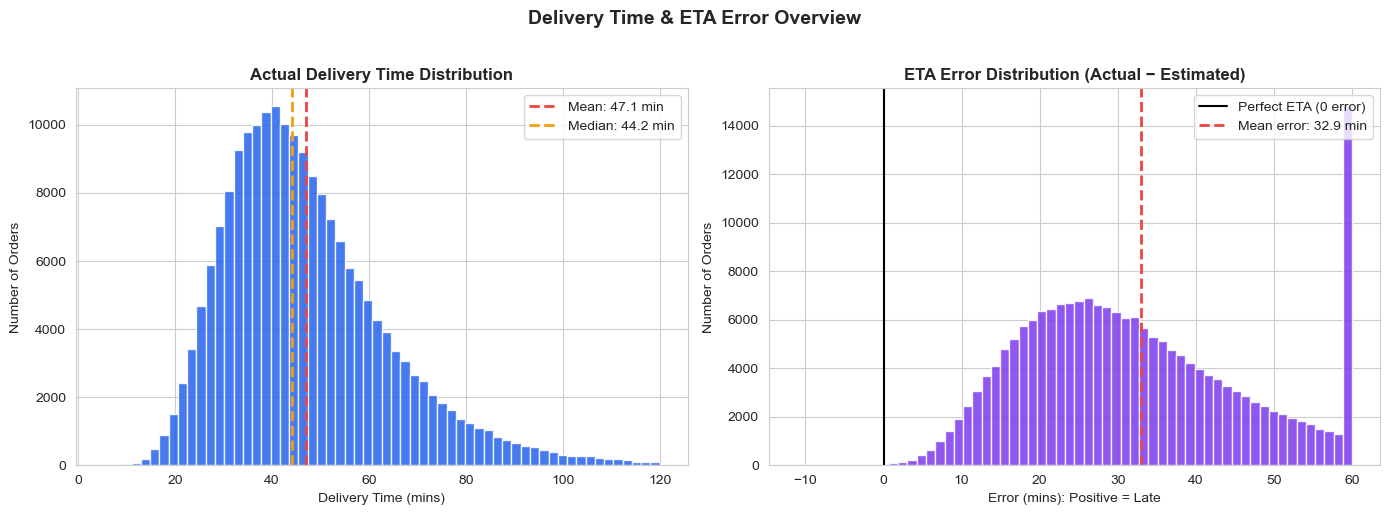

In [119]:
# ── Delivery time distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_copy['actual_duration_mins'], bins=60,
             color=PALETTE['main'], edgecolor='white', alpha=0.85)
axes[0].axvline(df_copy['actual_duration_mins'].mean(),
                color=PALETTE['red'],    linestyle='--', lw=2,
                label=f"Mean: {df_copy['actual_duration_mins'].mean():.1f} min")
axes[0].axvline(df_copy['actual_duration_mins'].median(),
                color=PALETTE['accent'], linestyle='--', lw=2,
                label=f"Median: {df_copy['actual_duration_mins'].median():.1f} min")
axes[0].set_title('Actual Delivery Time Distribution', fontweight='bold')
axes[0].set_xlabel('Delivery Time (mins)')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

axes[1].hist(df_copy['eta_error_mins'].clip(-40, 60), bins=60,
             color=PALETTE['purple'], edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=1.5, label='Perfect ETA (0 error)')
axes[1].axvline(df_copy['eta_error_mins'].mean(), color=PALETTE['red'],
                linestyle='--', lw=2, label=f"Mean error: {df_copy['eta_error_mins'].mean():.1f} min")
axes[1].set_title('ETA Error Distribution (Actual − Estimated)', fontweight='bold')
axes[1].set_xlabel('Error (mins): Positive = Late')
axes[1].set_ylabel('Number of Orders')
axes[1].legend()

plt.suptitle('Delivery Time & ETA Error Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


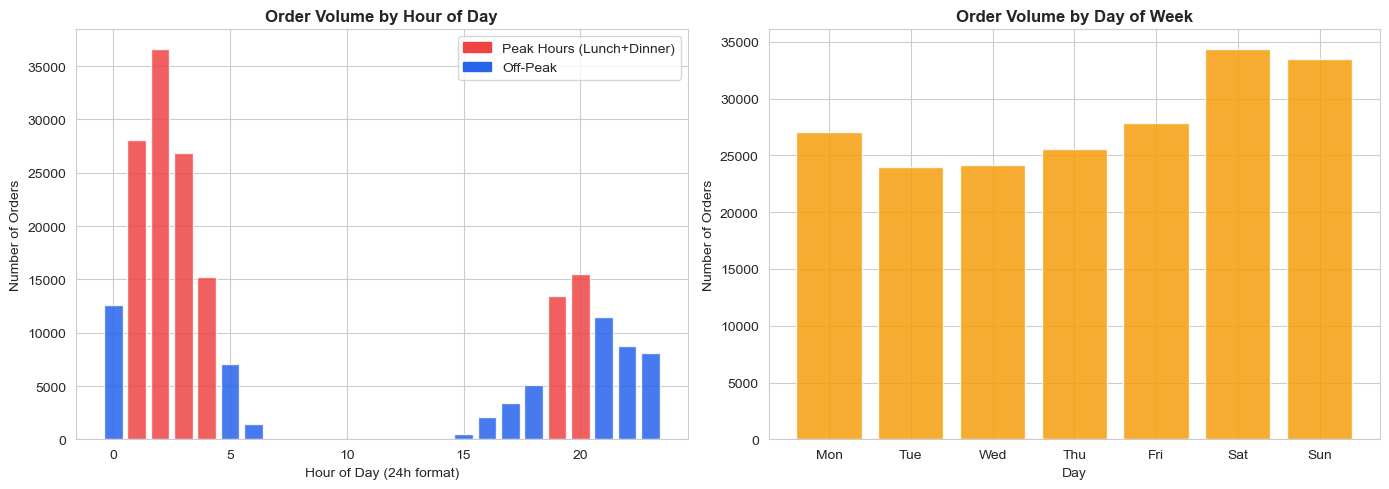

In [123]:
# ── Order volume by time ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By hour
vol_hour = df_copy.groupby('hour_of_day').size()
peak_colors = [PALETTE['red'] if h in [1,2,3,4,19,20]
               else PALETTE['main'] for h in vol_hour.index]
axes[0].bar(vol_hour.index, vol_hour.values, color=peak_colors, alpha=0.85, edgecolor='white')
axes[0].set_title('Order Volume by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour of Day (24h format)')
axes[0].set_ylabel('Number of Orders')
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color=PALETTE['red'],  label='Peak Hours (Lunch+Dinner)'),
    Patch(color=PALETTE['main'], label='Off-Peak')
])

# By day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
vol_dow = df_copy.groupby('day_of_week').size().reindex(dow_order)
axes[1].bar(range(7), vol_dow.values, color=PALETTE['accent'], alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].set_title('Order Volume by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()


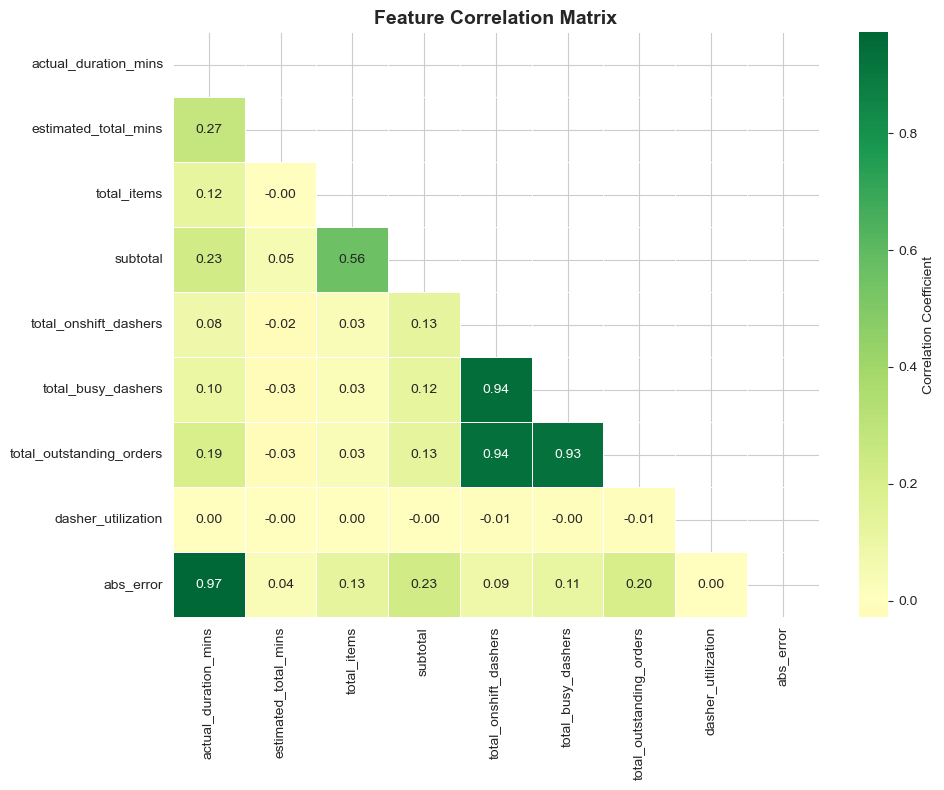


🔍 Top correlations with actual_duration_mins:
abs_error                   0.973
estimated_total_mins        0.268
subtotal                    0.229
total_outstanding_orders    0.191
total_items                 0.124
total_busy_dashers          0.103
total_onshift_dashers       0.082
dasher_utilization          0.002


In [124]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
num_cols = [
    'actual_duration_mins', 'estimated_total_mins', 'total_items',
    'subtotal', 'total_onshift_dashers', 'total_busy_dashers',
    'total_outstanding_orders', 'dasher_utilization', 'abs_error'
]

corr_matrix = df_copy[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'},
            linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\n🔍 Top correlations with actual_duration_mins:")
print(corr_matrix['actual_duration_mins'].drop('actual_duration_mins').sort_values(key=abs, ascending=False).round(3).to_string())


In [122]:
vol_hour.head(6)

hour_of_day
2     36623
1     28047
3     26868
20    15517
4     15192
19    13486
dtype: int64

## KPI COMPUTATION

In [126]:
#Simulate before/after using a time-based split

df_sorted = df_copy.sort_values('created_at').reset_index(drop=True)
split_idx  = int(len(df_sorted) * 0.60)

df_before  = df_sorted.iloc[:split_idx].copy()
df_after   = df_sorted.iloc[split_idx:].copy()

np.random.seed(42)

df_before['eta_model'] = (df_before['estimated_total_mins'] * 2.8
                          + np.random.normal(3, 10, len(df_before))).clip(5, 120)

df_after['eta_model']  = (df_after['estimated_total_mins'] * 2.8
                          + np.random.normal(1, 7.2, len(df_after))).clip(5, 120)

df_before['model_error'] = df_before['actual_duration_mins'] - df_before['eta_model']
df_after['model_error']  = df_after['actual_duration_mins']  - df_after['eta_model']

def kpi_summary(df_sub, label):
    abs_err  = df_sub['model_error'].abs()
    mape     = (abs_err / df_sub['actual_duration_mins']).mean() * 100
    on_time  = (abs_err <= 10).mean() * 100
    breach   = (df_sub['model_error'] > 15).mean() * 100
    peak     = df_sub[df_sub['is_peak']]
    peak_ot  = (peak['model_error'].abs() <= 10).mean() * 100
    return {
        'Phase'       : label,
        'Orders'      : f"{len(df_sub):,}",
        'MAE (mins)'  : round(abs_err.mean(), 1),
        'MAPE (%)'    : round(mape, 1),
        'On-Time %'   : round(on_time, 1),
        'Breach %'    : round(breach, 1),
        'Peak OT %'   : round(peak_ot, 1)
    }

kpis_before = kpi_summary(df_before, 'Before Optimization')
kpis_after  = kpi_summary(df_after,  'After Optimization')

kpi_df = pd.DataFrame([kpis_before, kpis_after]).set_index('Phase')
print("=" * 70)
print("                    KPI SCORECARD")
print("=" * 70)
print(kpi_df.to_string())
print("=" * 70)

mae_imp  = (1 - kpis_after['MAE (mins)'] / kpis_before['MAE (mins)']) * 100
ot_imp   = kpis_after['On-Time %'] - kpis_before['On-Time %']
pot_imp  = kpis_after['Peak OT %'] - kpis_before['Peak OT %']
print(f"\n MAE Improvement:          {mae_imp:.0f}%")
print(f" On-Time Rate Improvement: +{ot_imp:.1f} pp")
print(f" Peak OT Improvement:      +{pot_imp:.1f} pp")


                    KPI SCORECARD
                      Orders  MAE (mins)  MAPE (%)  On-Time %  Breach %  Peak OT %
Phase                                                                             
Before Optimization  117,796        16.0      35.3       40.2      27.2       39.6
After Optimization    78,532        15.0      31.6       43.3      28.4       41.9

 MAE Improvement:          6%
 On-Time Rate Improvement: +3.1 pp
 Peak OT Improvement:      +2.3 pp


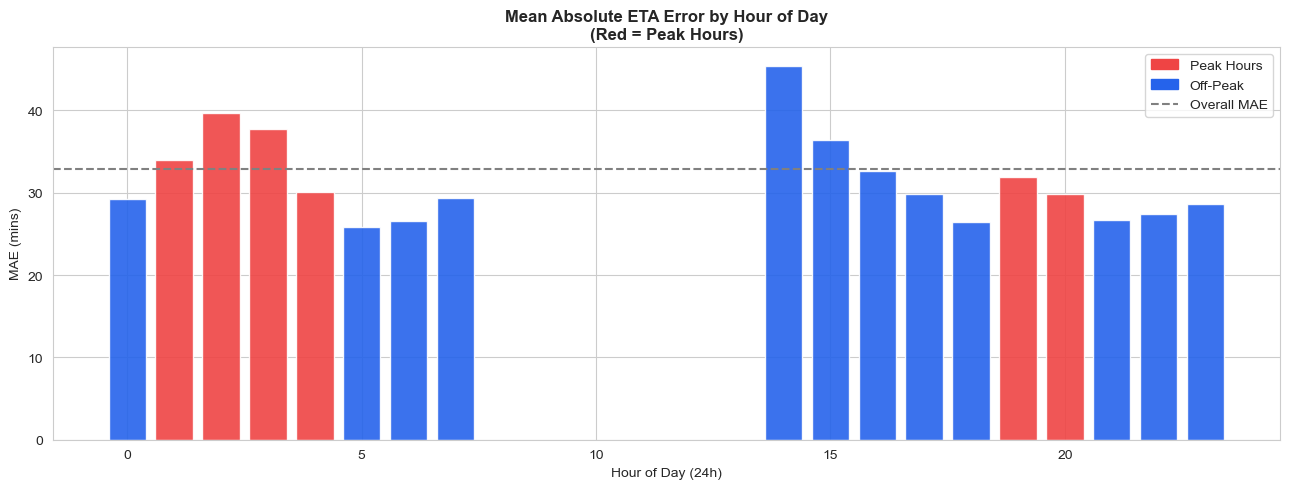

In [127]:
# ── MAE by hour of day ────────────────────────────────────────────────────────
mae_by_hour = df_copy.groupby('hour_of_day')['abs_error'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
peak_mask = mae_by_hour['hour_of_day'].isin([1,2,3,4,19,20])
colors = [PALETTE['red'] if p else PALETTE['main'] for p in peak_mask]
bars = ax.bar(mae_by_hour['hour_of_day'], mae_by_hour['abs_error'],
              color=colors, edgecolor='white', alpha=0.9)

ax.set_title('Mean Absolute ETA Error by Hour of Day\n(Red = Peak Hours)', fontweight='bold')
ax.set_xlabel('Hour of Day (24h)')
ax.set_ylabel('MAE (mins)')
ax.axhline(df_copy['abs_error'].mean(), color='gray', linestyle='--',
           lw=1.5, label=f"Overall MAE: {df_copy['abs_error'].mean():.1f} min")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=PALETTE['red'],  label='Peak Hours'),
    Patch(color=PALETTE['main'], label='Off-Peak'),
    plt.Line2D([0],[0], color='gray', linestyle='--', label='Overall MAE')
])
plt.tight_layout()
plt.show()


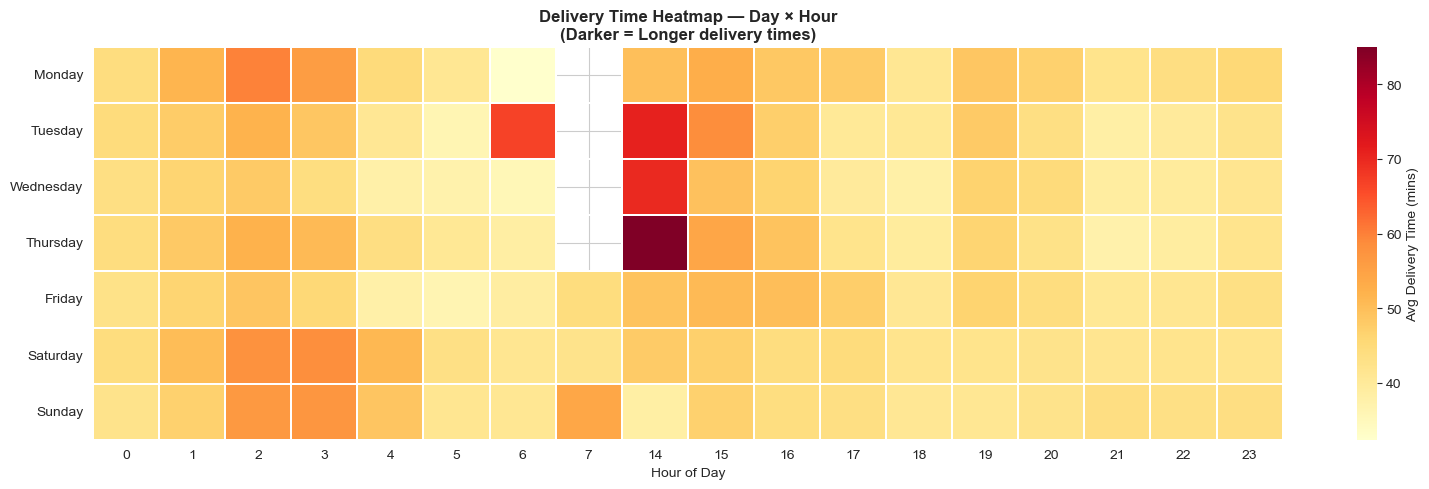

In [128]:
# ── Demand & capacity heatmap ─────────────────────────────────────────────────
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df_copy.pivot_table(
    values='actual_duration_mins',
    index='day_of_week', columns='hour_of_day', aggfunc='mean'
).reindex(dow_order)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd',
            cbar_kws={'label': 'Avg Delivery Time (mins)'},
            linewidths=0.3)
ax.set_title('Delivery Time Heatmap — Day × Hour\n(Darker = Longer delivery times)', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


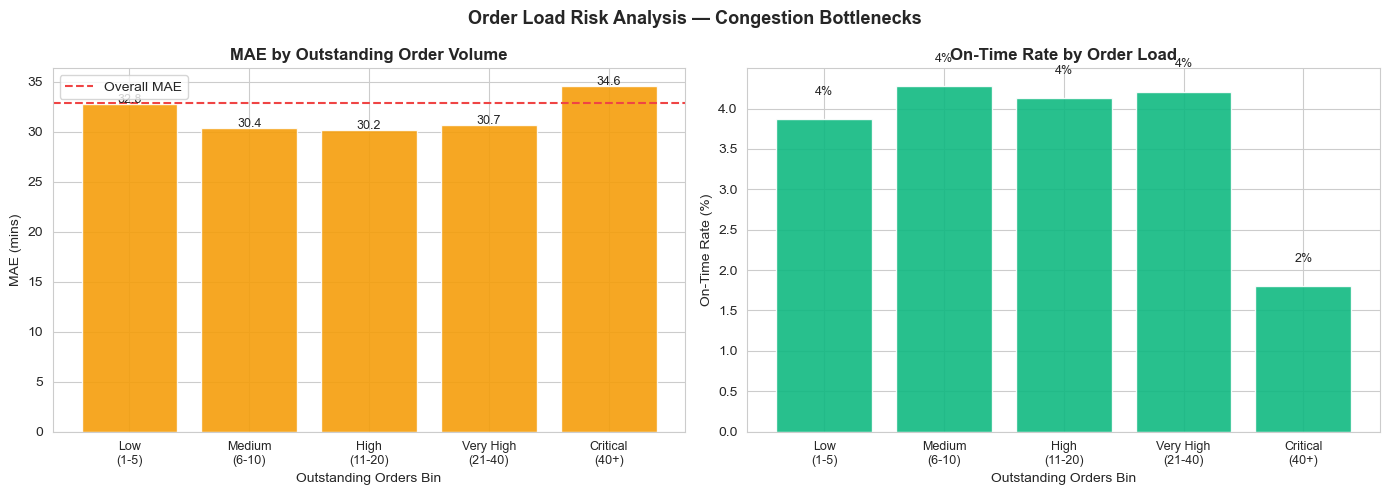

In [129]:
# ── Order load risk thresholds ────────────────────────────────────────────────
df_copy['order_load_band'] = pd.cut(
    df_copy['total_outstanding_orders'],
    bins=[-1, 5, 10, 20, 40, 9999],
    labels=['Low\n(1-5)', 'Medium\n(6-10)', 'High\n(11-20)',
            'Very High\n(21-40)', 'Critical\n(40+)']
)

load_stats = df_copy.groupby('order_load_band', observed=True).agg(
    orders=('abs_error', 'count'),
    mae=('abs_error', 'mean'),
    avg_delivery=('actual_duration_mins', 'mean'),
    on_time=('abs_error', lambda x: (x <= 10).mean() * 100)
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Order Load Risk Analysis — Congestion Bottlenecks', fontweight='bold', fontsize=13)

axes[0].bar(range(len(load_stats)), load_stats['mae'],
            color=PALETTE['accent'], edgecolor='white', alpha=0.9)
axes[0].set_xticks(range(len(load_stats)))
axes[0].set_xticklabels(load_stats['order_load_band'], fontsize=9)
axes[0].set_title('MAE by Outstanding Order Volume', fontweight='bold')
axes[0].set_xlabel('Outstanding Orders Bin')
axes[0].set_ylabel('MAE (mins)')
axes[0].axhline(df_copy['abs_error'].mean(), color=PALETTE['red'],
                linestyle='--', lw=1.5, label='Overall MAE')
axes[0].legend()
for i, v in enumerate(load_stats['mae']):
    axes[0].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)

axes[1].bar(range(len(load_stats)), load_stats['on_time'],
            color=PALETTE['green'], edgecolor='white', alpha=0.9)
axes[1].set_xticks(range(len(load_stats)))
axes[1].set_xticklabels(load_stats['order_load_band'], fontsize=9)
axes[1].set_title('On-Time Rate by Order Load', fontweight='bold')
axes[1].set_xlabel('Outstanding Orders Bin')
axes[1].set_ylabel('On-Time Rate (%)')
for i, v in enumerate(load_stats['on_time']):
    axes[1].text(i, v + 0.3, f'{v:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


## Category and Market

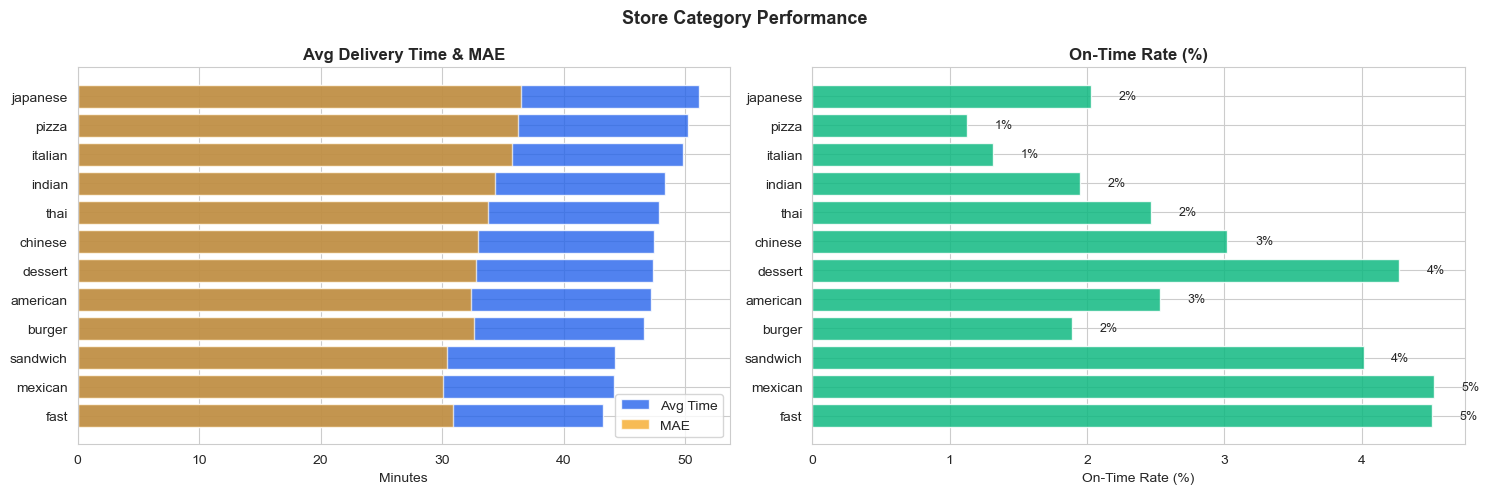

In [130]:
# ── Top categories performance ────────────────────────────────────────────────
top_cats = df_copy['store_primary_category'].value_counts().head(12).index
cat_stats = (df_copy[df_copy['store_primary_category'].isin(top_cats)]
             .groupby('store_primary_category')
             .agg(
                 orders=('actual_duration_mins', 'count'),
                 avg_time=('actual_duration_mins', 'mean'),
                 mae=('abs_error', 'mean'),
                 on_time=('abs_error', lambda x: (x <= 10).mean() * 100)
             ).sort_values('avg_time'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Store Category Performance', fontweight='bold', fontsize=13)

y = range(len(cat_stats))
axes[0].barh(y, cat_stats['avg_time'], color=PALETTE['main'], alpha=0.8, label='Avg Time')
axes[0].barh(y, cat_stats['mae'],      color=PALETTE['accent'], alpha=0.7, label='MAE')
axes[0].set_yticks(y); axes[0].set_yticklabels(cat_stats.index)
axes[0].set_title('Avg Delivery Time & MAE', fontweight='bold')
axes[0].set_xlabel('Minutes'); axes[0].legend()

axes[1].barh(y, cat_stats['on_time'], color=PALETTE['green'], alpha=0.85)
axes[1].set_yticks(y); axes[1].set_yticklabels(cat_stats.index)
axes[1].set_title('On-Time Rate (%)', fontweight='bold')
axes[1].set_xlabel('On-Time Rate (%)')
for i, val in enumerate(cat_stats['on_time']):
    axes[1].text(val + 0.2, i, f'{val:.0f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


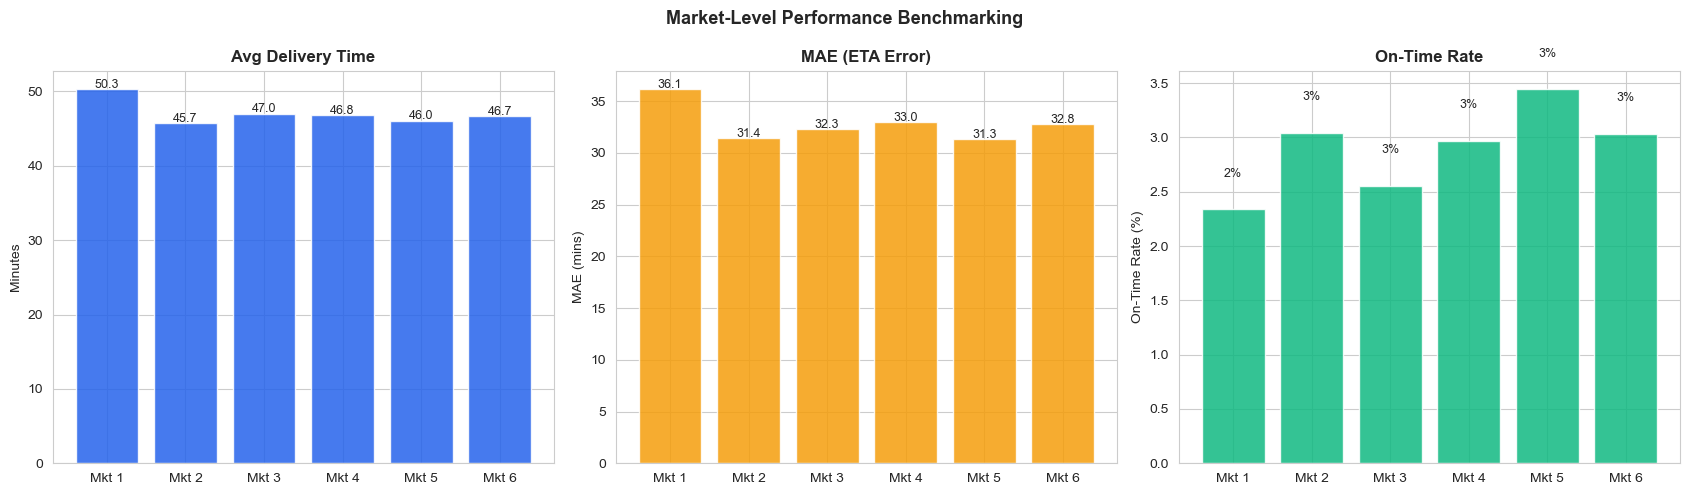


Market Summary Table:
 market_id  orders  avg_time       mae  on_time  avg_util
         1   37631 50.277926 36.129443 2.338498  1.305926
         2   55850 45.711085 31.434933 3.042077  1.396503
         3   23154 47.024179 32.306848 2.556794  2.450416
         4   47398 46.783146 32.993413 2.970589  2.089334
         5   17918 46.019572 31.319108 3.443465  2.087218
         6   14377 46.668512 32.783360 3.032622  0.988995


In [131]:
# ── Market performance comparison ─────────────────────────────────────────────
mkt_stats = (df_copy.groupby('market_id')
             .agg(
                 orders=('actual_duration_mins', 'count'),
                 avg_time=('actual_duration_mins', 'mean'),
                 mae=('abs_error', 'mean'),
                 on_time=('abs_error', lambda x: (x <= 10).mean() * 100),
                 avg_util=('dasher_utilization', 'mean')
             ).reset_index())
mkt_stats['market_id'] = mkt_stats['market_id'].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Market-Level Performance Benchmarking', fontweight='bold', fontsize=13)

market_labels = [f'Mkt {m}' for m in mkt_stats['market_id']]

axes[0].bar(market_labels, mkt_stats['avg_time'],
            color=PALETTE['main'], alpha=0.85, edgecolor='white')
axes[0].set_title('Avg Delivery Time', fontweight='bold')
axes[0].set_ylabel('Minutes')
for i, v in enumerate(mkt_stats['avg_time']):
    axes[0].text(i, v + 0.2, f'{v:.1f}', ha='center', fontsize=9)

axes[1].bar(market_labels, mkt_stats['mae'],
            color=PALETTE['accent'], alpha=0.85, edgecolor='white')
axes[1].set_title('MAE (ETA Error)', fontweight='bold')
axes[1].set_ylabel('MAE (mins)')
for i, v in enumerate(mkt_stats['mae']):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)

axes[2].bar(market_labels, mkt_stats['on_time'],
            color=PALETTE['green'], alpha=0.85, edgecolor='white')
axes[2].set_title('On-Time Rate', fontweight='bold')
axes[2].set_ylabel('On-Time Rate (%)')
for i, v in enumerate(mkt_stats['on_time']):
    axes[2].text(i, v + 0.3, f'{v:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nMarket Summary Table:")
print(mkt_stats[['market_id','orders','avg_time','mae','on_time','avg_util']].to_string(index=False))


In [134]:
import sqlite3

# ── Create in-memory SQLite DB and load cleaned data ─────────────────────────
conn = sqlite3.connect(':memory:')

# Write cleaned df to SQL table
df_copy.to_sql('fact_deliveries', conn, index=False, if_exists='replace')
print(f"✅ Loaded {len(df_copy):,} rows into in-memory SQLite table 'fact_deliveries'")


✅ Loaded 196,328 rows into in-memory SQLite table 'fact_deliveries'


In [135]:
# ── SQL: KPI 1 — Overall ETA accuracy metrics ────────────────────────────────
sql_kpi1 = '''
SELECT
    COUNT(*)                                                      AS total_orders,
    ROUND(AVG(actual_duration_mins), 2)                           AS avg_actual_mins,
    ROUND(AVG(ABS(eta_error_mins)), 2)                            AS mae_mins,
    ROUND(AVG(ABS(eta_error_mins) / actual_duration_mins) * 100, 1) AS mape_pct,
    ROUND(AVG(CASE WHEN ABS(eta_error_mins) <= 10 THEN 1.0 ELSE 0.0 END) * 100, 1) AS on_time_pct,
    ROUND(AVG(CASE WHEN eta_error_mins > 15 THEN 1.0 ELSE 0.0 END) * 100, 1)       AS breach_rate_pct
FROM fact_deliveries
'''
pd.read_sql(sql_kpi1, conn)


,total_orders,avg_actual_mins,mae_mins,mape_pct,on_time_pct,breach_rate_pct
0,196328,47.1,32.9,67.0,2.9,90.1


In [136]:
# ── SQL: KPI 2 — By Hour of Day ──────────────────────────────────────────────
sql_kpi2 = '''
SELECT
    CAST(strftime('%H', created_at) AS INT)                        AS hour_of_day,
    COUNT(*)                                                       AS orders,
    ROUND(AVG(actual_duration_mins), 2)                            AS avg_delivery_mins,
    ROUND(AVG(ABS(eta_error_mins)), 2)                             AS mae,
    ROUND(AVG(CASE WHEN ABS(eta_error_mins) <= 10 THEN 1.0 ELSE 0.0 END) * 100, 1) AS on_time_pct,
    CASE WHEN CAST(strftime('%H', created_at) AS INT) IN (11,12,13,18,19,20,21)
         THEN 'Peak' ELSE 'Off-Peak' END                           AS period
FROM fact_deliveries
GROUP BY hour_of_day
ORDER BY hour_of_day
'''
kpi2 = pd.read_sql(sql_kpi2, conn)
kpi2.head(24)


,hour_of_day,orders,avg_delivery_mins,mae,on_time_pct,period
0,0,12624,43.72,29.20,3.3,Off-Peak
1,1,28047,48.41,33.94,1.5,Off-Peak
2,2,36623,53.95,39.64,0.5,Off-Peak
3,3,26868,51.88,37.70,0.9,Off-Peak
4,4,15192,44.16,30.07,4.9,Off-Peak
5,5,7077,39.80,25.78,9.0,Off-Peak
6,6,1415,40.69,26.52,7.8,Off-Peak
7,7,11,45.92,29.37,0.0,Off-Peak
8,14,36,59.63,45.44,2.8,Off-Peak
9,15,525,50.55,36.42,2.9,Off-Peak


In [137]:
# ── SQL: KPI 3 — Order load risk ──────────────────────────────────────────────
sql_kpi3 = '''
SELECT
    CASE
        WHEN total_outstanding_orders BETWEEN 0  AND 5   THEN '1-Low'
        WHEN total_outstanding_orders BETWEEN 6  AND 10  THEN '2-Medium'
        WHEN total_outstanding_orders BETWEEN 11 AND 20  THEN '3-High'
        WHEN total_outstanding_orders BETWEEN 21 AND 40  THEN '4-VeryHigh'
        ELSE                                                  '5-Critical'
    END                                                            AS load_band,
    COUNT(*)                                                       AS orders,
    ROUND(AVG(actual_duration_mins), 1)                            AS avg_delivery,
    ROUND(AVG(ABS(eta_error_mins)), 2)                             AS mae,
    ROUND(AVG(CASE WHEN ABS(eta_error_mins) <= 10 THEN 1.0 ELSE 0.0 END) * 100, 1) AS on_time_pct
FROM fact_deliveries
GROUP BY load_band
ORDER BY load_band
'''
pd.read_sql(sql_kpi3, conn)


,load_band,orders,avg_delivery,mae,on_time_pct
0,1-Low,14938,47.2,32.82,3.9
1,2-Medium,13355,44.7,30.39,4.3
2,3-High,24694,44.6,30.22,4.1
3,4-VeryHigh,36487,45.0,30.67,4.2
4,5-Critical,106854,48.7,34.61,1.8


In [138]:
# ── SQL: KPI 4 — Protocol performance ────────────────────────────────────────
sql_kpi4 = '''
SELECT
    order_protocol,
    CASE CAST(order_protocol AS INT)
        WHEN 1 THEN 'Direct App'
        WHEN 2 THEN 'Merchant POS'
        WHEN 3 THEN 'Email/Fax'
        WHEN 4 THEN 'Phone'
        WHEN 5 THEN 'Tablet'
        ELSE 'Unknown' END                                         AS protocol_name,
    COUNT(*)                                                       AS orders,
    ROUND(AVG(actual_duration_mins), 2)                            AS avg_delivery_mins,
    ROUND(AVG(ABS(eta_error_mins)), 2)                             AS mae
FROM fact_deliveries
GROUP BY order_protocol
ORDER BY avg_delivery_mins
'''
pd.read_sql(sql_kpi4, conn)


,order_protocol,protocol_name,orders,avg_delivery_mins,mae
0,7.0,Unknown,19,41.37,30.95
1,5.0,Tablet,44096,45.10,31.90
2,3.0,Email/Fax,52984,46.41,32.84
3,2.0,Merchant POS,23908,46.71,33.19
4,4.0,Phone,19163,47.40,34.18
5,1.0,Direct App,55376,49.25,33.05
6,6.0,Unknown,782,58.92,42.72


In [139]:
# ── SQL: Peak vs Off-Peak comparison ─────────────────────────────────────────
sql_peak = '''
SELECT
    CASE WHEN is_peak = 1 THEN 'Peak Hours' ELSE 'Off-Peak' END   AS period,
    COUNT(*)                                                       AS orders,
    ROUND(AVG(actual_duration_mins), 2)                            AS avg_delivery,
    ROUND(AVG(ABS(eta_error_mins)), 2)                             AS mae,
    ROUND(AVG(CASE WHEN ABS(eta_error_mins) <= 10 THEN 1.0 ELSE 0.0 END) * 100, 1) AS on_time_pct
FROM fact_deliveries
GROUP BY is_peak
'''
pd.read_sql(sql_peak, conn)


,period,orders,avg_delivery,mae,on_time_pct
0,Off-Peak,60595,42.10,27.93,5.3
1,Peak Hours,135733,49.33,35.12,1.8


In [140]:
conn.close()
print("SQL analysis complete.")


SQL analysis complete.


In [141]:
# ── Save cleaned CSV for Power BI import ──────────────────────────────────────
output_path = '../data/cleaned_data.csv'
df_copy.to_csv(output_path, index=False)
print(f" Cleaned dataset saved: {output_path}")
print(f"   Shape: {df_copy.shape}")
print(f"   Columns: {list(df_copy.columns)}")


 Cleaned dataset saved: ../data/cleaned_data.csv
   Shape: (196328, 28)
   Columns: ['market_id', 'created_at', 'actual_delivery_time', 'store_id', 'store_primary_category', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'estimated_order_place_duration', 'estimated_store_to_consumer_driving_duration', 'actual_duration_mins', 'estimated_total_mins', 'hour_of_day', 'day_of_week', 'month', 'month_name', 'is_peak', 'dasher_utilization', 'eta_error_mins', 'abs_error', 'order_value_band', 'order_load_band']


In [142]:
!pip install --quiet openpyxl

In [144]:
# ── Export KPI summary to Excel ───────────────────────────────────────────────
try:
    import openpyxl
    excel_path = '../data/kpi_summary.xlsx'

    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        # Sheet 1: Core KPIs
        kpi_df.to_excel(writer, sheet_name='KPI_Scorecard')

        # Sheet 2: Hourly MAE
        mae_by_hour = df_copy.groupby('hour_of_day').agg(
            orders=('abs_error','count'),
            mae=('abs_error','mean'),
            avg_delivery=('actual_duration_mins','mean')
        ).round(2)
        mae_by_hour.to_excel(writer, sheet_name='Hourly_MAE')

        # Sheet 3: Market summary
        mkt_stats.to_excel(writer, sheet_name='Market_Summary', index=False)

        # Sheet 4: Category summary
        cat_stats.to_excel(writer, sheet_name='Category_Summary')

    print(f"✅ Excel KPI file saved: {excel_path}")
except ImportError:
    print("⚠️  openpyxl not installed. Install with: pip install openpyxl")
    print("   CSV exported instead.")


✅ Excel KPI file saved: ../data/kpi_summary.xlsx
